# 项目名称 — 模块说明

| 项目   | 内容 |
|--------|------|
| 课程   | 数据分析与经济决策（ds2026） |
| 题目   | T-B2_美联储货币政策与全球资产价格传导 |
| 小组   | 第 4 组 |
| 成员   | 25210227 荣渝渝| 25210229 沈仕沐| 25210246 王丽娜| 25210257 吴玥| 25210271 连伊丽| 25210275 薛佳程| 25210285 易忠凯|
| GitHub | https://github.com/zhongerhenglu/ds2026-G04-T-B2_FedPolicyAssets |
| Pages  | https://zhongerhenglu.github.io/ds2026-G04-T-B2_FedPolicyAssets/ |
| 日期   | 2026-05-16 |

# 王丽娜：任务 3b — 加息 / 降息周期资产收益对比可视化

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('output', exist_ok=True)

# 设置中文字体（Windows 系统推荐 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

In [13]:
# 读取清洗后的数据
df = pd.read_csv('data_clean/macro_assets_merged.csv', index_col=0, parse_dates=True)
print(f'数据范围: {df.index[0].strftime("%Y-%m")} ~ {df.index[-1].strftime("%Y-%m")}')
print(f'数据维度: {df.shape}')
df.head()

数据范围: 1993-01 ~ 2026-05
数据维度: (401, 11)


,fedfunds,m2,pce_yoy,SP500,Nasdaq100,VIX,Bitcoin,DXY,Gold_ETF,TBond_20Y,cycle
1993-01-31,3.02,3419.1,NaN,NaN,NaN,12.42,NaN,NaN,NaN,NaN,neutral
1993-02-28,3.03,3414.5,NaN,NaN,NaN,13.16,NaN,NaN,NaN,NaN,neutral
1993-03-31,3.07,3411.7,NaN,NaN,NaN,12.53,NaN,NaN,NaN,NaN,neutral
1993-04-30,2.96,3411.3,NaN,NaN,NaN,12.42,NaN,NaN,NaN,NaN,neutral
1993-05-31,3.00,3436.9,NaN,NaN,NaN,13.47,NaN,NaN,NaN,NaN,neutral


---
## 图 2：各类资产在加息 vs 降息周期中的平均月度收益

In [15]:
# 定义分析用的资产列
asset_cols = ['SP500', 'Nasdaq100', 'Gold_ETF', 'TBond_20Y', 'DXY']
available = [col for col in asset_cols if col in df.columns]
print(f'可用资产列: {available}')

# 计算月度收益率（百分比）
returns = df[available].pct_change() * 100
returns['cycle'] = df['cycle']
returns_plot = returns[returns['cycle'] != 'neutral'].dropna()
print(f'有效观测: {len(returns_plot)} 个月')

可用资产列: ['SP500', 'Nasdaq100', 'Gold_ETF', 'TBond_20Y', 'DXY']
有效观测: 93 个月


In [16]:
# 按周期类型分组计算
cycle_mean = returns_plot.groupby('cycle')[available].mean()
cycle_std  = returns_plot.groupby('cycle')[available].std()

print('各周期类型下的平均月度收益率（%）:')
display(cycle_mean)
print('\n各周期类型下的月度收益率标准差（%）:')
display(cycle_std)

各周期类型下的平均月度收益率（%）:


,SP500,Nasdaq100,Gold_ETF,TBond_20Y,DXY
cycle,,,,,
cut,1.364761,2.019704,1.851528,0.673714,0.001193
hike,0.720572,1.228097,0.104162,2.366005,0.165581



各周期类型下的月度收益率标准差（%）:


,SP500,Nasdaq100,Gold_ETF,TBond_20Y,DXY
cycle,,,,,
cut,4.577762,5.175524,4.381945,10.706624,1.541467
hike,4.105668,5.505350,3.599921,7.731088,1.634893


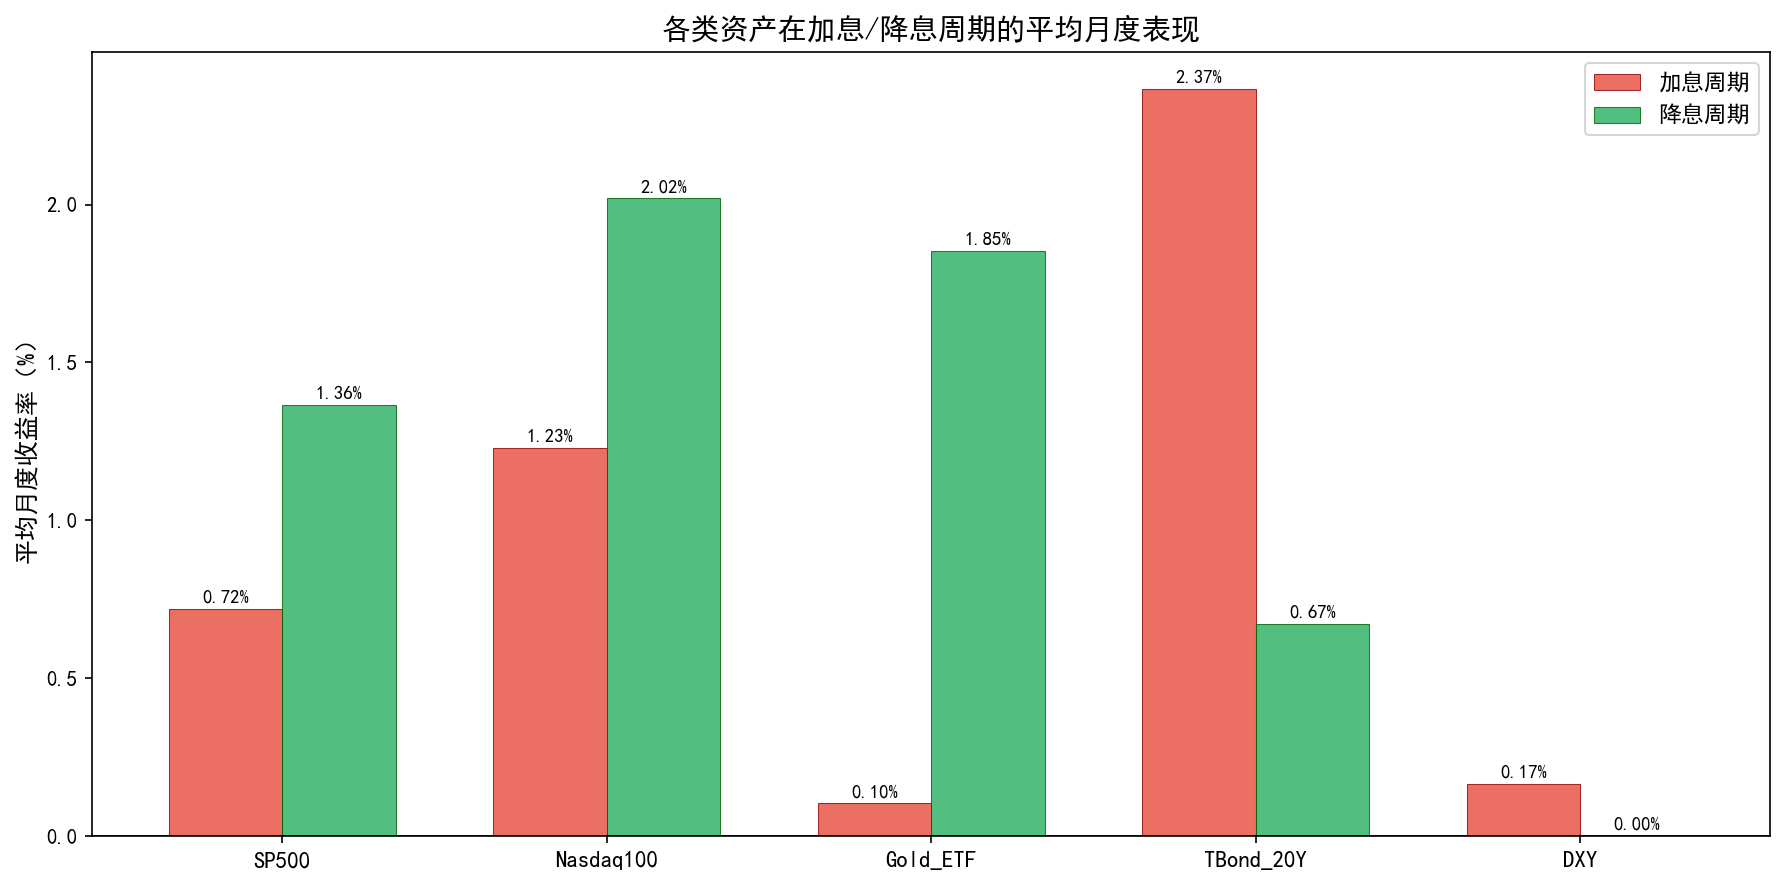

已保存: output/fig_cycle_performance.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(available))
width = 0.35

hike_vals = [cycle_mean.loc['hike', col] if 'hike' in cycle_mean.index else 0 for col in available]
cut_vals  = [cycle_mean.loc['cut', col] if 'cut' in cycle_mean.index else 0 for col in available]

bars1 = ax.bar(x - width/2, hike_vals, width, label='加息周期',
               color='#e74c3c', alpha=0.8, edgecolor='darkred', linewidth=0.5)
bars2 = ax.bar(x + width/2, cut_vals, width, label='降息周期',
               color='#27ae60', alpha=0.8, edgecolor='darkgreen', linewidth=0.5)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(available, fontsize=11)
ax.set_ylabel('平均月度收益率（%）', fontsize=12)
ax.set_title('各类资产在加息/降息周期的平均月度表现', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

# 在柱子上显示数值
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        offset = 3 if h >= 0 else -15
        ax.annotate(f'{h:.2f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, offset), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/fig_cycle_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('已保存: output/fig_cycle_performance.png')

In [18]:
# 按具体周期明细分析
returns['period'] = '其他'
for i, (start, end, label) in enumerate(cycles, 1):
    period_name = f'{start}~{end}'
    mask = (returns.index >= start) & (returns.index <= end)
    returns.loc[mask, 'period'] = period_name

period_perf = returns.groupby('period')[available].mean()
print('各具体周期资产平均月度收益率（%）:')
display(period_perf.round(2))

各具体周期资产平均月度收益率（%）:


,SP500,Nasdaq100,Gold_ETF,TBond_20Y,DXY
period,,,,,
1994-02~1995-02,NaN,NaN,NaN,1.87,NaN
1995-07~1998-09,NaN,NaN,NaN,-0.46,NaN
1999-06~2000-05,NaN,NaN,NaN,0.26,NaN
2001-01~2003-06,NaN,NaN,NaN,-0.75,NaN
2004-06~2006-06,0.55,NaN,NaN,0.06,-0.41
2007-09~2015-12,0.46,1.19,NaN,-0.31,0.20
2015-12~2018-12,0.82,1.18,0.08,0.76,0.11
2019-07~2022-03,1.38,2.10,1.04,0.71,0.03
2022-03~2023-07,0.29,0.72,0.14,4.13,0.24
